https://www.techwithtim.net/tutorials/python-programming/sudoku-solver-backtracking/

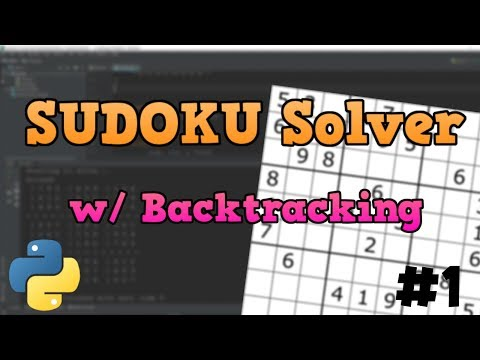

In [7]:
#@title https://youtu.be/eqUwSA0xI-s
from IPython.display import YouTubeVideo
YouTubeVideo('eqUwSA0xI-s')

# Part 1
In part 1 of this Sudoku solver with python tutorial I explain how we are going to go about solving the problem and discuss the algorithm known as backtracking. Backtracking is simply reverting back to the previous step or solution as soon as we determine that our current solution cannot be continued into a complete one. We will use this principle of backtracking to implement the following algorithm.

<iframe width="420" height="315" src=http://www.youtube.com/embed/U3iNcBtycaQ frameborder="4"></iframe>

## Algorithm

Starting with an incomplete board:

1. Find some empty space
2. Attempt to place the digits 1-9 in that space
3. Check if that digit is valid in the current spot based on the current board
  1. If the digit is valid, recursively attempt to fill the board using steps 1-3.
  2. If it is not valid, reset the square you just filled and go back to the previous step.


5. Once the board is full by the definition of this algorithm we have found a solution.


We will finish about half of the algorithm in part 1. In part 2 (look below) we will implement the entire algorithm.

In [5]:
board = [
    [7,8,0,4,0,0,1,2,0],
    [6,0,0,0,7,5,0,0,9],
    [0,0,0,6,0,1,0,7,8],
    [0,0,7,0,4,0,2,6,0],
    [0,0,1,0,5,0,9,3,0],
    [9,0,4,0,6,0,0,0,5],
    [0,7,0,3,0,0,0,1,2],
    [1,2,0,0,0,7,4,0,0],
    [0,4,9,2,0,6,0,0,7]
]

def print_board(bo):
    for i in range(len(bo)):
        if i % 3 == 0 and i != 0:
            print("- - - - - - - - - - - - - ")

        for j in range(len(bo[0])):
            if j % 3 == 0 and j != 0:
                print(" | ", end="")

            if j == 8:
                print(bo[i][j])
            else:
                print(str(bo[i][j]) + " ", end="")


def find_empty(bo):
    for i in range(len(bo)):
        for j in range(len(bo[0])):
            if bo[i][j] == 0:
                return (i, j)  # row, col

    return None

# Part 2

In [4]:
#@title https://youtu.be/lK4N8E6uNr4
from IPython.display import YouTubeVideo
YouTubeVideo('https://youtu.be/lK4N8E6uNr4')

In part 2 of this tutorial we will finish the algorithm and continue to understand how it works by running through our code step by step. We will use a recursive function to implement the algorithm explained in part 1.

## Part 2 Code

In [185]:
def find_empty(b):
    for i in (0,1,2,3,4,5,6,7,8):
        for j in (0,1,2,3,4,5,6,7,8):
            if b[i][j] == 0:
                return (i, j)

def find_empty(b):
    max_pos = None
    max_val = 0
    for i in (0,1,2,3,4,5,6,7,8):
        for j in (0,1,2,3,4,5,6,7,8):
            if b[i][j] == 0:
                val = len([x for x in b[i] if x!=0])
                val += sum([b[row][j]!=0 for row in (0,1,2,3,4,5,6,7,8)])
                for row in range((i//3)*3, (i//3)*3 + 3):
                    for col in range((j//3) * 3, (j//3)*3 + 3):
                        val += b[row][col] != 0
                if (val > max_val):
                    max_pos = (i,j)
                    max_val = val

    return max_pos

def solve(b):
    find = find_empty(b)
    if not find: return True
    
    row, col = find

    #global numbers
    #if not numbers:
    import collections
    c = collections.Counter()
    for b_i in b: c.update(b_i)
    numbers = sorted((1,2,3,4,5,6,7,8,9), key=lambda x: c.setdefault(x, 0), reverse=True)

    for num in numbers:
        if not valid(b, num, (row, col)): continue
        b[row][col] = num
        if solve(b): return True
    
    b[row][col] = 0
    return False

def valid(b, num, pos):
    for i in (0,1,2,3,4,5,6,7,8):
        if (b[pos[0]][i] == num and pos[1] != i) or (b[i][pos[1]] == num and pos[0] != i):
            return False
    for i in range((pos[0] // 3)*3, (pos[0] // 3)*3 + 3):
        for j in range((pos[1] // 3) * 3, (pos[1] // 3)*3 + 3):
            if b[i][j] == num and (i,j) != pos:
                return False
    return True


board = [[7,8,0,4,0,0,1,2,0],
         [6,0,0,0,7,5,0,0,9],
         [0,0,0,6,0,1,0,7,8],
         [0,0,7,0,4,0,2,6,0],
         [0,0,1,0,5,0,9,3,0],
         [9,0,4,0,6,0,0,0,5],
         [0,7,0,3,0,0,0,1,2],
         [1,2,0,0,0,7,4,0,0],
         [0,4,9,2,0,6,0,0,7]]


s  = '.....6....59.....82....8....45........3........6..3.54...325..6..................'
#s = '.....5.8....6.1.43..........1.5........1.6...3.......553.....61........4.........'
board = [[int(s[r*9+c]) if s[r*9+c]!='.' else 0 for c in range(9)] for r in range(9)]

def print_board(b):
    for i in (0,1,2,3,4,5,6,7,8):
        if i % 3 == 0 and i != 0: print("- - - - - - - - - - -")
        for j in (0,1,2,3,4,5,6,7,8):
            c = b[i][j] if b[i][j] != 0 else " "
            if j % 3 == 0 and j != 0: print("| ", end="")
            print(c) if j==8 else print(f"{c} ", end="")

print_board(board)
solve(board)
print("_____________________")
print_board(board)

      |     6 |      
  5 9 |       |     8
2     |     8 |      
- - - - - - - - - - -
  4 5 |       |      
    3 |       |      
    6 |     3 |   5 4
- - - - - - - - - - -
      | 3 2 5 |     6
      |       |      
      |       |      
_____________________
4 8 1 | 7 5 6 | 2 3 9
3 5 9 | 4 1 2 | 6 7 8
2 6 7 | 9 3 8 | 1 4 5
- - - - - - - - - - -
9 4 5 | 2 6 7 | 3 8 1
1 7 3 | 5 8 4 | 9 6 2
8 2 6 | 1 9 3 | 7 5 4
- - - - - - - - - - -
7 1 8 | 3 2 5 | 4 9 6
5 3 2 | 6 4 9 | 8 1 7
6 9 4 | 8 7 1 | 5 2 3


In [119]:
b = [[7,8,0,4,0,0,1,2,0],
         [6,0,0,0,7,5,0,0,9],
         [0,0,0,6,0,1,0,7,8],
         [0,0,7,0,4,0,2,6,0],
         [0,0,1,0,5,0,9,3,0],
         [9,0,4,0,6,0,0,0,5],
         [0,7,0,3,0,0,0,1,2],
         [1,2,0,0,0,7,4,0,0],
         [0,4,9,2,0,6,0,0,7]]



def most_restricted(b):
    import itertools
    import collections
    rowcount = {row: len([x for x in b[row] if x != 0]) for row in (0,1,2,3,4,5,6,7,8)}
    colcount = {col: sum([b[row][col]!=0 for row in (0,1,2,3,4,5,6,7,8)]) for col in (0,1,2,3,4,5,6,7,8)}

    posses = {}
    for pos in itertools.product((0,1,2,3,4,5,6,7,8),(0,1,2,3,4,5,6,7,8)):
        bcount = rowcount[pos[0]] + colcount[pos[1]]
        for i in range((pos[0] // 3)*3, (pos[0] // 3)*3 + 3):
            for j in range((pos[1] // 3) * 3, (pos[1] // 3)*3 + 3):
                bcount +=  b[i][j]!=0
        posses[pos] = bcount
    from collections import Counter
    return Counter(d).most_common()[0][0]


import collections
c = collections.Counter()
for b_i in b: c.update(b_i)
numbers = sorted((1,2,3,4,5,6,7,8,9), key=lambda x: c.setdefault(x, 0), reverse=True)

[7, 1, 2, 4, 6, 9, 5, 3, 8]


In [173]:


d = {(1,2):4, (3,2):1}
c = Counter(d)
c.elements



<bound method Counter.elements of Counter({(1, 2): 4, (3, 2): 1})>

# Building the GUI

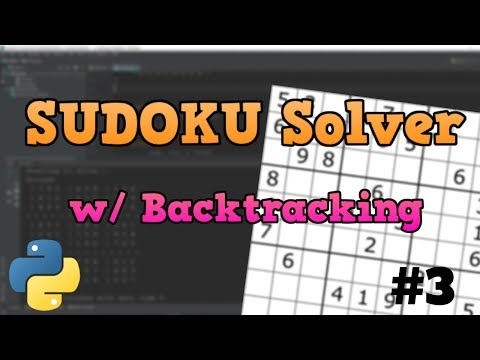

In [47]:
#@title https://youtu.be/_Z9Mz2V-Mig
from IPython.display import YouTubeVideo
YouTubeVideo("_Z9Mz2V-Mig")

## GUI Code
For this GUI to work it must be inside the same directory as the file called solver.py. You must also have pygame installed on your system. To learn how to download/install pygame watch this video:
https://www.youtube.com/watch?v=AdUZArA-kZw

Download Code: https://techwithtim.net/wp-content/uploads/2019/04/Sudoku-Game.zip

In [ ]:
#@title GUI.py

# GUI.py
import pygame
from solver import solve, valid
import time
pygame.font.init()


class Grid:
    board = [
        [7, 8, 0, 4, 0, 0, 1, 2, 0],
        [6, 0, 0, 0, 7, 5, 0, 0, 9],
        [0, 0, 0, 6, 0, 1, 0, 7, 8],
        [0, 0, 7, 0, 4, 0, 2, 6, 0],
        [0, 0, 1, 0, 5, 0, 9, 3, 0],
        [9, 0, 4, 0, 6, 0, 0, 0, 5],
        [0, 7, 0, 3, 0, 0, 0, 1, 2],
        [1, 2, 0, 0, 0, 7, 4, 0, 0],
        [0, 4, 9, 2, 0, 6, 0, 0, 7]
    ]

    def __init__(self, rows, cols, width, height):
        self.rows = rows
        self.cols = cols
        self.cubes = [[Cube(self.board[i][j], i, j, width, height) for j in range(cols)] for i in range(rows)]
        self.width = width
        self.height = height
        self.model = None
        self.selected = None

    def update_model(self):
        self.model = [[self.cubes[i][j].value for j in range(self.cols)] for i in range(self.rows)]

    def place(self, val):
        row, col = self.selected
        if self.cubes[row][col].value == 0:
            self.cubes[row][col].set(val)
            self.update_model()

            if valid(self.model, val, (row,col)) and solve(self.model):
                return True
            else:
                self.cubes[row][col].set(0)
                self.cubes[row][col].set_temp(0)
                self.update_model()
                return False

    def sketch(self, val):
        row, col = self.selected
        self.cubes[row][col].set_temp(val)

    def draw(self, win):
        # Draw Grid Lines
        gap = self.width / 9
        for i in range(self.rows+1):
            if i % 3 == 0 and i != 0:
                thick = 4
            else:
                thick = 1
            pygame.draw.line(win, (0,0,0), (0, i*gap), (self.width, i*gap), thick)
            pygame.draw.line(win, (0, 0, 0), (i * gap, 0), (i * gap, self.height), thick)

        # Draw Cubes
        for i in range(self.rows):
            for j in range(self.cols):
                self.cubes[i][j].draw(win)

    def select(self, row, col):
        # Reset all other
        for i in range(self.rows):
            for j in range(self.cols):
                self.cubes[i][j].selected = False

        self.cubes[row][col].selected = True
        self.selected = (row, col)

    def clear(self):
        row, col = self.selected
        if self.cubes[row][col].value == 0:
            self.cubes[row][col].set_temp(0)

    def click(self, pos):
        """
        :param: pos
        :return: (row, col)
        """
        if pos[0] < self.width and pos[1] < self.height:
            gap = self.width / 9
            x = pos[0] // gap
            y = pos[1] // gap
            return (int(y),int(x))
        else:
            return None

    def is_finished(self):
        for i in range(self.rows):
            for j in range(self.cols):
                if self.cubes[i][j].value == 0:
                    return False
        return True


class Cube:
    rows = 9
    cols = 9

    def __init__(self, value, row, col, width ,height):
        self.value = value
        self.temp = 0
        self.row = row
        self.col = col
        self.width = width
        self.height = height
        self.selected = False

    def draw(self, win):
        fnt = pygame.font.SysFont("comicsans", 40)

        gap = self.width / 9
        x = self.col * gap
        y = self.row * gap

        if self.temp != 0 and self.value == 0:
            text = fnt.render(str(self.temp), 1, (128,128,128))
            win.blit(text, (x+5, y+5))
        elif not(self.value == 0):
            text = fnt.render(str(self.value), 1, (0, 0, 0))
            win.blit(text, (x + (gap/2 - text.get_width()/2), y + (gap/2 - text.get_height()/2)))

        if self.selected:
            pygame.draw.rect(win, (255,0,0), (x,y, gap ,gap), 3)

    def set(self, val):
        self.value = val

    def set_temp(self, val):
        self.temp = val


def redraw_window(win, board, time, strikes):
    win.fill((255,255,255))
    # Draw time
    fnt = pygame.font.SysFont("comicsans", 40)
    text = fnt.render("Time: " + format_time(time), 1, (0,0,0))
    win.blit(text, (540 - 160, 560))
    # Draw Strikes
    text = fnt.render("X " * strikes, 1, (255, 0, 0))
    win.blit(text, (20, 560))
    # Draw grid and board
    board.draw(win)


def format_time(secs):
    sec = secs%60
    minute = secs//60
    hour = minute//60

    mat = " " + str(minute) + ":" + str(sec)
    return mat


def main():
    win = pygame.display.set_mode((540,600))
    pygame.display.set_caption("Sudoku")
    board = Grid(9, 9, 540, 540)
    key = None
    run = True
    start = time.time()
    strikes = 0
    while run:

        play_time = round(time.time() - start)

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                run = False
            if event.type == pygame.KEYDOWN:
                if event.key == pygame.K_1:
                    key = 1
                if event.key == pygame.K_2:
                    key = 2
                if event.key == pygame.K_3:
                    key = 3
                if event.key == pygame.K_4:
                    key = 4
                if event.key == pygame.K_5:
                    key = 5
                if event.key == pygame.K_6:
                    key = 6
                if event.key == pygame.K_7:
                    key = 7
                if event.key == pygame.K_8:
                    key = 8
                if event.key == pygame.K_9:
                    key = 9
                if event.key == pygame.K_DELETE:
                    board.clear()
                    key = None
                if event.key == pygame.K_RETURN:
                    i, j = board.selected
                    if board.cubes[i][j].temp != 0:
                        if board.place(board.cubes[i][j].temp):
                            print("Success")
                        else:
                            print("Wrong")
                            strikes += 1
                        key = None

                        if board.is_finished():
                            print("Game over")
                            run = False

            if event.type == pygame.MOUSEBUTTONDOWN:
                pos = pygame.mouse.get_pos()
                clicked = board.click(pos)
                if clicked:
                    board.select(clicked[0], clicked[1])
                    key = None

        if board.selected and key != None:
            board.sketch(key)

        redraw_window(win, board, play_time, strikes)
        pygame.display.update()


main()
pygame.quit()

In [ ]:
#@title solver.py

# solver.py

def solve(bo):
    find = find_empty(bo)
    if not find:
        return True
    else:
        row, col = find

    for i in range(1,10):
        if valid(bo, i, (row, col)):
            bo[row][col] = i

            if solve(bo):
                return True

            bo[row][col] = 0

    return False


def valid(bo, num, pos):
    # Check row
    for i in range(len(bo[0])):
        if bo[pos[0]][i] == num and pos[1] != i:
            return False

    # Check column
    for i in range(len(bo)):
        if bo[i][pos[1]] == num and pos[0] != i:
            return False

    # Check box
    box_x = pos[1] // 3
    box_y = pos[0] // 3

    for i in range(box_y*3, box_y*3 + 3):
        for j in range(box_x * 3, box_x*3 + 3):
            if bo[i][j] == num and (i,j) != pos:
                return False

    return True


def print_board(bo):
    for i in range(len(bo)):
        if i % 3 == 0 and i != 0:
            print("- - - - - - - - - - - - - ")

        for j in range(len(bo[0])):
            if j % 3 == 0 and j != 0:
                print(" | ", end="")

            if j == 8:
                print(bo[i][j])
            else:
                print(str(bo[i][j]) + " ", end="")


def find_empty(bo):
    for i in range(len(bo)):
        for j in range(len(bo[0])):
            if bo[i][j] == 0:
                return (i, j)  # row, col

    return None
